In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from src.shared.json_tools import load_json_long
from paths import ROOT_DIR

np.random.seed(42)  # for reproducibility
X = []
y = []

for file in (ROOT_DIR / "unified_data_proc").glob("*.json"):
    data = load_json_long(file)
    targets = [int(i["target"] >= 0.5) for i in data]
    features = [i["content"] for i in data]

    features = np.array(features)
    targets = np.array(targets)

    pos_indices = np.where(targets == 1)[0]
    neg_indices = np.where(targets == 0)[0]

    min_class_count = min(100, len(pos_indices), len(neg_indices))
    pos_sample = np.random.choice(pos_indices, min_class_count, replace=False)
    neg_sample = np.random.choice(neg_indices, min_class_count, replace=False)

    balanced_indices = np.concatenate([pos_sample, neg_sample])
    np.random.shuffle(balanced_indices)

    features_balanced = features[balanced_indices]
    y_balanced = targets[balanced_indices]

    X = X + features_balanced.tolist()
    y = y + y_balanced.tolist()

In [3]:
len(X)

4486

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

def evaluate(y_true, y_pred):
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

    print("\nClassification Report:\n", classification_report(y_true, y_pred))

    print(confusion_matrix(y_true, y_pred))

In [6]:
params = {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 0, 'reg_alpha': 1, 'reg_lambda': 1, 'min_child_weight': 1}

Using device: cuda


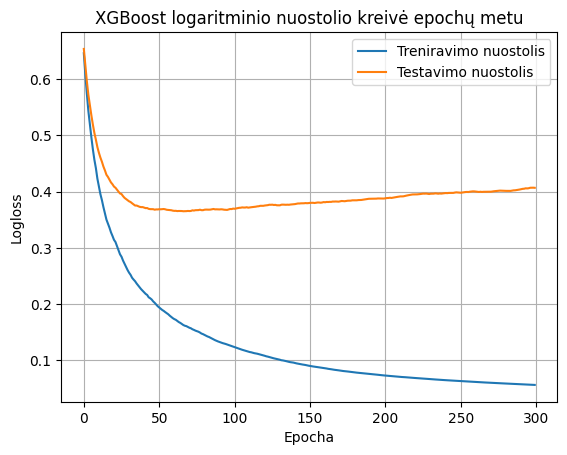

In [7]:
from xgboost import XGBClassifier
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

params = {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'gamma': 0, 'reg_alpha': 1, 'reg_lambda': 1, 'min_child_weight': 1}

X_train_gpu = torch.from_numpy(np.array(X_train)).to(device)
y_train_gpu = torch.from_numpy(np.array(y_train)).to(device)

X_test_gpu = torch.from_numpy(np.array(X_test)).to(device)
eval_set = [(X_train_gpu, y_train_gpu), (X_test_gpu, y_test)]
model = XGBClassifier(
    device="cuda",  # ensure both training and prediction use GPU
    eval_metric="logloss",
    random_state=42,
    **params
)

model.fit(X_train_gpu, y_train_gpu, eval_set=eval_set, verbose=False)

# After training, get the logloss curves
results = model.evals_result()

# Plot them
import matplotlib.pyplot as plt

epochs = range(len(results['validation_0']['logloss']))
plt.plot(epochs, results['validation_0']['logloss'], label='Treniravimo nuostolis')
plt.plot(epochs, results['validation_1']['logloss'], label='Testavimo nuostolis')
plt.xlabel('Epocha')
plt.ylabel('Logloss')
plt.title('XGBoost logaritminio nuostolio kreivė epochų metu')
plt.legend()
plt.grid(True)
plt.show()

Using device: cuda


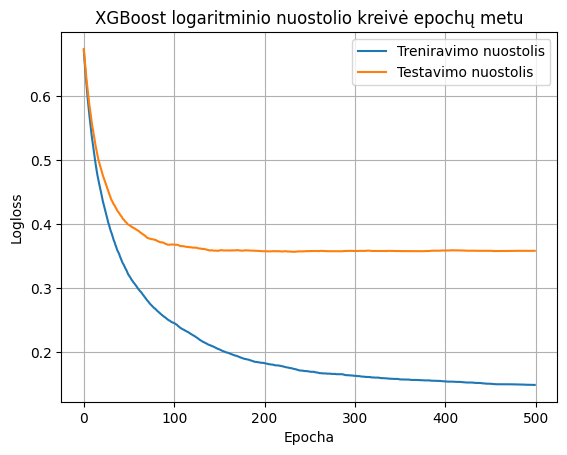

In [8]:
from xgboost import XGBClassifier
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

params = {
    'n_estimators': 500,
    'max_depth': 7,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 1,
    'reg_alpha': 1,
    'reg_lambda': 1,
    'min_child_weight': 5
}


X_train_gpu = torch.from_numpy(np.array(X_train)).to(device)
y_train_gpu = torch.from_numpy(np.array(y_train)).to(device)

X_test_gpu = torch.from_numpy(np.array(X_test)).to(device)
eval_set = [(X_train_gpu, y_train_gpu), (X_test_gpu, y_test)]
model = XGBClassifier(
    device="cuda",  # ensure both training and prediction use GPU
    eval_metric="logloss",
    random_state=42,
    **params
)

model.fit(X_train_gpu, y_train_gpu, eval_set=eval_set, verbose=False)

# After training, get the logloss curves
results = model.evals_result()

# Plot them
import matplotlib.pyplot as plt

epochs = range(len(results['validation_0']['logloss']))
plt.plot(epochs, results['validation_0']['logloss'], label='Treniravimo nuostolis')
plt.plot(epochs, results['validation_1']['logloss'], label='Testavimo nuostolis')
plt.xlabel('Epocha')
plt.ylabel('Logloss')
plt.title('XGBoost logaritminio nuostolio kreivė epochų metu')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
y_pred = model.predict(X_train_gpu)
evaluate(y_train, y_pred)

Accuracy: 0.9738015607580826
Precision: 0.9896253602305476
Recall: 0.9576129392080313
F1 Score: 0.9733560090702947

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97      1795
           1       0.99      0.96      0.97      1793

    accuracy                           0.97      3588
   macro avg       0.97      0.97      0.97      3588
weighted avg       0.97      0.97      0.97      3588

[[1777   18]
 [  76 1717]]


In [10]:
y_pred = model.predict(X_test_gpu)
evaluate(y_test, y_pred)

Accuracy: 0.8340757238307349
Precision: 0.8508158508158508
Recall: 0.8111111111111111
F1 Score: 0.8304891922639362

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       448
           1       0.85      0.81      0.83       450

    accuracy                           0.83       898
   macro avg       0.83      0.83      0.83       898
weighted avg       0.83      0.83      0.83       898

[[384  64]
 [ 85 365]]


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from src.data.aggregator_accelerated import get_labels

labels = get_labels()

# Basic feature importance
importances = model.feature_importances_

# Create a DataFrame for sorting and plotting
feat_importance_df = pd.DataFrame({
    'Feature': labels,  # replace with your column names if needed
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_importance_df = feat_importance_df[feat_importance_df['Importance'] >= 0.02]  # Filter out low importance features
feat_importance_df

,Feature,Importance
25,thirty_sec_bash_count_rate,0.162256
27,thirty_sec_unique_pids,0.073266
33,five_min_avg_embedded_command_5,0.036929
4,cur_event_avg_embedded_command_4,0.033928
1,cur_event_avg_embedded_command_1,0.033539
17,thirty_sec_avg_embedded_command_6,0.028769
19,thirty_sec_avg_embedded_command_8,0.027669
26,thirty_sec_success_rate,0.027108
42,five_min_bash_count_rate,0.026362
13,thirty_sec_avg_embedded_command_2,0.026168


In [14]:
# Get list of feature names that passed the threshold
important_features = feat_importance_df['Feature'].tolist()

# Get their original indexes from the labels list
important_indexes = [labels.index(f) for f in important_features]

print(important_indexes)

[25, 27, 33, 4, 1, 17, 19, 26, 42, 13, 7, 5, 6, 9, 43]


In [15]:
len(important_indexes)

15

Using device: cuda


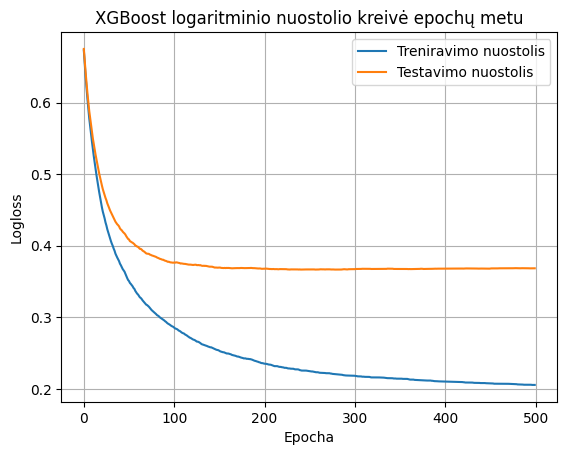

In [18]:
from xgboost import XGBClassifier
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

params = {
    'n_estimators': 500,
    'max_depth': 7,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 1,
    'reg_alpha': 1,
    'reg_lambda': 1,
    'min_child_weight': 5
}


X_train_gpu = torch.from_numpy(np.array(X_train)[:, important_indexes]).to(device)
y_train_gpu = torch.from_numpy(np.array(y_train)).to(device)
X_test_gpu = torch.from_numpy(np.array(X_test)[:, important_indexes]).to(device)
eval_set = [(X_train_gpu, y_train_gpu), (X_test_gpu, y_test)]

model = XGBClassifier(
    device="cuda",  # ensure both training and prediction use GPU
    eval_metric="logloss",
    random_state=42,
    **params
)

model.fit(X_train_gpu, y_train_gpu, eval_set=eval_set, verbose=False)

# After training, get the logloss curves
results = model.evals_result()

# Plot them
import matplotlib.pyplot as plt

epochs = range(len(results['validation_0']['logloss']))
plt.plot(epochs, results['validation_0']['logloss'], label='Treniravimo nuostolis')
plt.plot(epochs, results['validation_1']['logloss'], label='Testavimo nuostolis')
plt.xlabel('Epocha')
plt.ylabel('Logloss')
plt.title('XGBoost logaritminio nuostolio kreivė epochų metu')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
y_pred = model.predict(X_train_gpu)
evaluate(y_train, y_pred)

Accuracy: 0.9417502787068004
Precision: 0.9604651162790697
Recall: 0.9213608477412158
F1 Score: 0.9405066894392258

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94      1795
           1       0.96      0.92      0.94      1793

    accuracy                           0.94      3588
   macro avg       0.94      0.94      0.94      3588
weighted avg       0.94      0.94      0.94      3588

[[1727   68]
 [ 141 1652]]


In [20]:
y_pred = model.predict(X_test_gpu)
evaluate(y_test, y_pred)

Accuracy: 0.8318485523385301
Precision: 0.8568019093078759
Recall: 0.7977777777777778
F1 Score: 0.8262370540851554

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       448
           1       0.86      0.80      0.83       450

    accuracy                           0.83       898
   macro avg       0.83      0.83      0.83       898
weighted avg       0.83      0.83      0.83       898

[[388  60]
 [ 91 359]]


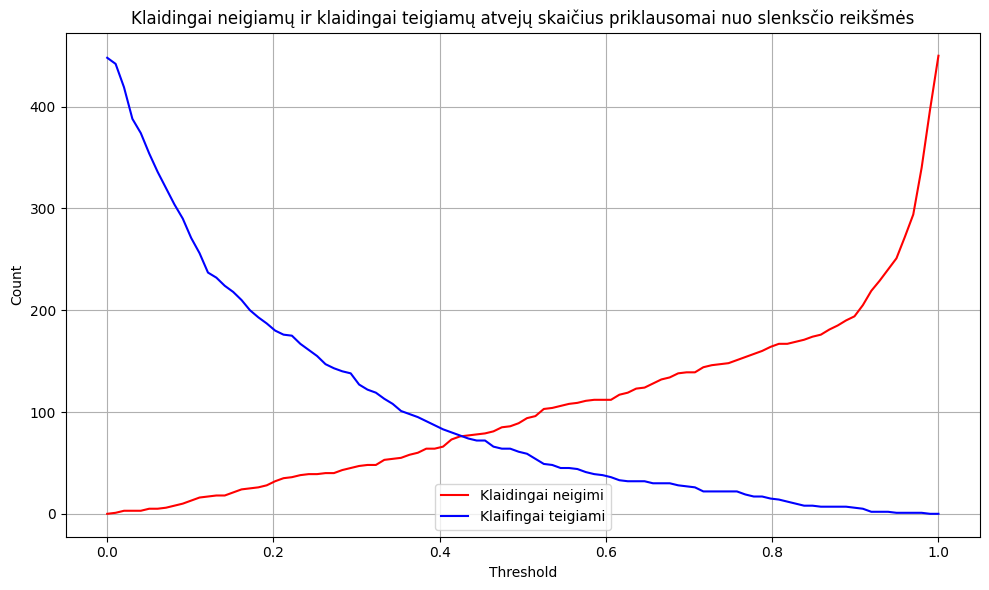

In [21]:
import matplotlib.pyplot as plt
y_pred_prob = model.predict_proba(X_test_gpu)[:, 1]

# Thresholds to evaluate
thresholds = np.linspace(0, 1, 100)
false_negatives = []
false_positives = []

# Calculate FN and FP for each threshold
for threshold in thresholds:
    y_pred = (y_pred_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    false_negatives.append(fn)
    false_positives.append(fp)

# Plotting both FN and FP
plt.figure(figsize=(10, 6))
plt.plot(thresholds, false_negatives, label='Klaidingai neigimi', color='red')
plt.plot(thresholds, false_positives, label='Klaifingai teigiami', color='blue')
plt.xlabel('Threshold')
plt.ylabel('Count')
plt.title("Klaidingai neigiamų ir klaidingai teigiamų atvejų skaičius priklausomai nuo slenksčio reikšmės")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

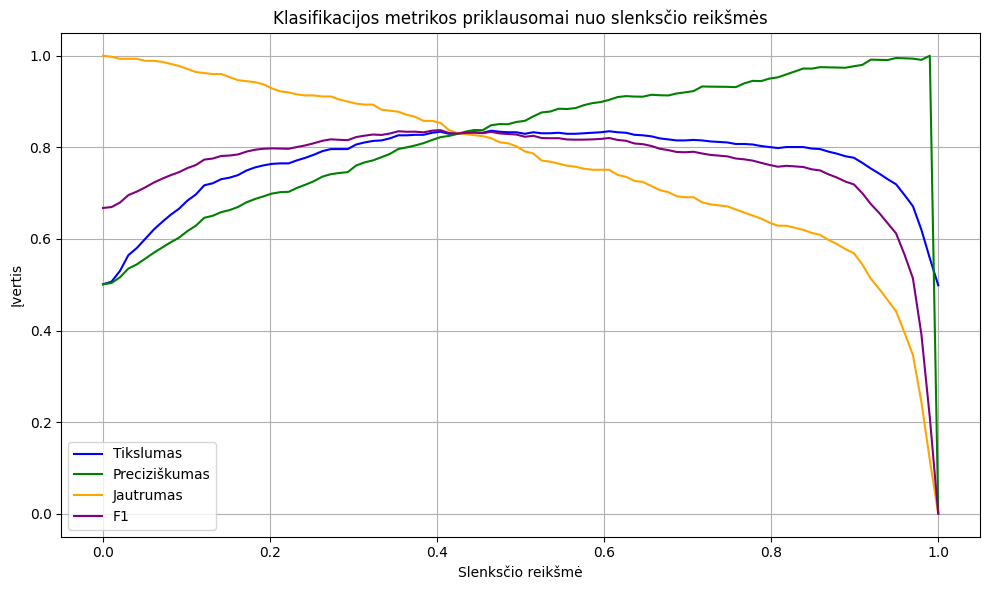

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_prob = model.predict_proba(X_test_gpu)[:, 1]

# Define thresholds to evaluate
thresholds = np.linspace(0, 1, 100)

# Metrics to store
accuracies = []
precisions = []
recalls = []
f1s = []

# Compute metrics for each threshold
for threshold in thresholds:
    y_pred = (y_pred_prob >= threshold).astype(int)
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred, zero_division=0))
    f1s.append(f1_score(y_test, y_pred, zero_division=0))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, accuracies, label='Tikslumas', color='blue')
plt.plot(thresholds, precisions, label='Preciziškumas', color='green')
plt.plot(thresholds, recalls, label='Jautrumas', color='orange')
plt.plot(thresholds, f1s, label='F1', color='purple')
plt.xlabel('Slenksčio reikšmė')
plt.ylabel('Įvertis')
plt.title('Klasifikacijos metrikos priklausomai nuo slenksčio reikšmės')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [23]:
y_proba = model.predict_proba(X_train_gpu)[:, 1]

# Apply custom threshold
threshold = 0.4  # or 0.7, 0.4 etc.
y_pred = (y_proba >= threshold).astype(int)
evaluate(y_train, y_pred)

Accuracy: 0.93561872909699
Precision: 0.9239956568946797
Recall: 0.9492470719464584
F1 Score: 0.9364511691884456

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.92      0.93      1795
           1       0.92      0.95      0.94      1793

    accuracy                           0.94      3588
   macro avg       0.94      0.94      0.94      3588
weighted avg       0.94      0.94      0.94      3588

[[1655  140]
 [  91 1702]]


In [24]:
y_proba = model.predict_proba(X_test_gpu)[:, 1]

# Apply custom threshold
threshold = 0.4  # or 0.7, 0.4 etc.
y_pred = (y_proba >= threshold).astype(int)
evaluate(y_test, y_pred)

Accuracy: 0.8351893095768375
Precision: 0.8226495726495726
Recall: 0.8555555555555555
F1 Score: 0.8387799564270153

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.81      0.83       448
           1       0.82      0.86      0.84       450

    accuracy                           0.84       898
   macro avg       0.84      0.84      0.84       898
weighted avg       0.84      0.84      0.84       898

[[365  83]
 [ 65 385]]


In [25]:
# Save the model
import pickle
from paths import MODEL_DIR

model_path = MODEL_DIR / "xgboost_retrained.pkl"
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

## All data

In [26]:
import numpy as np
from src.shared.json_tools import load_json_long
from paths import ROOT_DIR

np.random.seed(42)  # for reproducibility
X = []
y = []

for file in (ROOT_DIR / "unified_data_proc").glob("*.json"):
    data = load_json_long(file)
    targets = [int(i["target"] >= 0.5) for i in data]
    features = [i["content"] for i in data]


    X = X + features
    y = y + targets

In [27]:
X_test_gpu = torch.from_numpy(np.array(X)[:, [25, 27, 33, 4, 1, 17, 19, 26, 42, 13, 7, 5, 6, 9, 43]]).to(device)

In [28]:
y_proba = model.predict_proba(X_test_gpu)[:, 1]

# Apply custom threshold
threshold = 0.4  # or 0.7, 0.4 etc.
y_pred = (y_proba >= threshold).astype(int)
evaluate(y, y_pred)

Accuracy: 0.7602114315449292
Precision: 0.5899837181940268
Recall: 0.8425492192803802
F1 Score: 0.694001943199849

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.72      0.80    123645
           1       0.59      0.84      0.69     58920

    accuracy                           0.76    182565
   macro avg       0.75      0.78      0.75    182565
weighted avg       0.80      0.76      0.77    182565

[[89145 34500]
 [ 9277 49643]]


In [29]:
from paths import ROOT_DIR
with open(ROOT_DIR / "models/xgboost_model.pkl", 'rb') as f:
    old_model = pickle.load(f)

In [30]:
X_test_gpu = torch.from_numpy(np.array(X)[:, [25, 15, 11, 18, 19, 20, 21, 16, 14, 13, 12, 26, 17, 0, 6, 27, 32, 42, 33, 9, 7, 4, 2, 43, 5, 38, 3, 1, 8]]).to(device)

In [31]:
y_proba = old_model.predict_proba(X_test_gpu)[:, 1]

# Apply custom threshold
threshold = 0.5  # or 0.7, 0.4 etc.
y_pred = (y_proba >= threshold).astype(int)
evaluate(y, y_pred)

Accuracy: 0.6472324925369046
Precision: 0.4390466238299575
Recall: 0.3351493550577054
F1 Score: 0.3801264714091841

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.80      0.75    123645
           1       0.44      0.34      0.38     58920

    accuracy                           0.65    182565
   macro avg       0.58      0.57      0.57    182565
weighted avg       0.63      0.65      0.63    182565

[[98415 25230]
 [39173 19747]]


In [33]:
from src.data.aggregator_accelerated import get_selected_labels_after_update

a = get_selected_labels_after_update()

In [34]:
a

['thirty_sec_bash_count_rate',
 'thirty_sec_unique_pids',
 'five_min_avg_embedded_command_5',
 'cur_event_avg_embedded_command_4',
 'cur_event_avg_embedded_command_1',
 'thirty_sec_avg_embedded_command_6',
 'thirty_sec_avg_embedded_command_8',
 'thirty_sec_success_rate',
 'five_min_bash_count_rate',
 'thirty_sec_avg_embedded_command_2',
 'cur_event_avg_embedded_command_7',
 'cur_event_avg_embedded_command_5',
 'cur_event_avg_embedded_command_6',
 'cur_event_avg_embedded_command_9',
 'five_min_success_rate']

In [35]:
sorted(a)

['cur_event_avg_embedded_command_1',
 'cur_event_avg_embedded_command_4',
 'cur_event_avg_embedded_command_5',
 'cur_event_avg_embedded_command_6',
 'cur_event_avg_embedded_command_7',
 'cur_event_avg_embedded_command_9',
 'five_min_avg_embedded_command_5',
 'five_min_bash_count_rate',
 'five_min_success_rate',
 'thirty_sec_avg_embedded_command_2',
 'thirty_sec_avg_embedded_command_6',
 'thirty_sec_avg_embedded_command_8',
 'thirty_sec_bash_count_rate',
 'thirty_sec_success_rate',
 'thirty_sec_unique_pids']

In [42]:
import cupy as cp
c = cp.array([1,2,3,4,5,6,7,8,9,0])
c[[2,4,5]]

array([3, 5, 6])